# LISTA 05 AMA

#### Aluno: Jônatas Fernandes Silva
#### Matrícula: 603243

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, auc, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

#### Montando drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


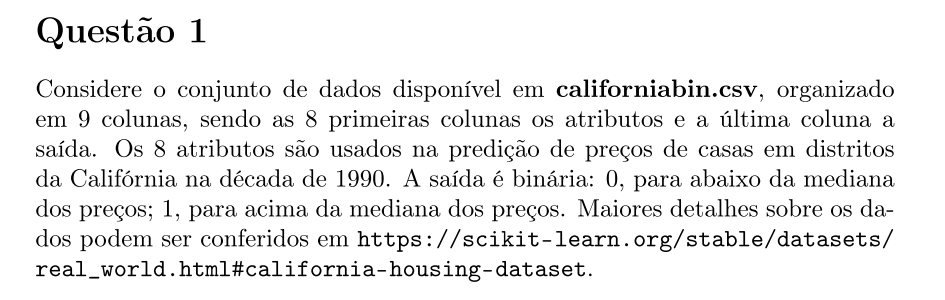

#### Carregando dados

In [3]:
df = np.genfromtxt('/content/californiabin.csv', delimiter=',')

In [4]:
X = df[:,:-1]
y = df[:,-1].astype(int)
print(f"Número de amostras: {X.shape[0]}")
print(f"Número de dimensões: {X.shape[1]}")
print(f"Amostras por classe: {np.unique(y, return_counts=True)}")

Número de amostras: 2000
Número de dimensões: 8
Amostras por classe: (array([0, 1]), array([1000, 1000]))


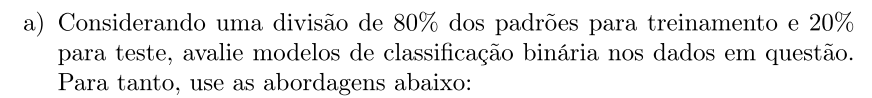

#### Data split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## GRID SEARCH

### Interno

In [6]:
def inner_loop(x, y, model_class, grid, internal_kfold=10, scale_flag=True, verbose=True, random_state=12345):
    param_names = list(grid.keys())
    grid_search = np.meshgrid(*grid.values())
    grid_search = np.hstack([ np.atleast_2d(g.ravel()).T for g in grid_search ], dtype='object')

    # internal loop
    best_score = -np.inf
    best_params = None

    for combination in grid_search:
        params = {
            param_names[i]:combination[i] for i in range(len(param_names))
        }

        kf_in = KFold(n_splits=internal_kfold, shuffle=True, random_state=random_state)
        fold_scores = []

        for train_idx, val_idx in kf_in.split(x):
            x_train, x_val = x[train_idx], x[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            if scale_flag:
                scaler = StandardScaler()
                x_train = scaler.fit_transform(x_train)
                x_val = scaler.transform(x_val)

            model = model_class(**params)
            model.fit(x_train, y_train)
            y_pred = model.predict(x_val)

            fold_scores.append(accuracy_score(y_val, y_pred))

        if np.mean(fold_scores) > best_score:
            best_score = np.mean(fold_scores)
            best_params = params

    return best_params

### Externo

In [7]:
def run_nested_cv(x, y, model_class, grid, external_kfold=5, internal_kfold=5, scale_flag=True, verbose=True, random_state=12345):
    metrics = {'acc': [], 'rec': [], 'prec': [], 'f1': [], 'roc_auc': [], 'roc_curve': [], 'pr_auc': [], 'pr_curve': [], 'conf_mat': []}

    # external loop
    kf_out = KFold(n_splits=external_kfold, shuffle=True, random_state=random_state)

    for fold_idx, (train_idx, test_idx) in enumerate(kf_out.split(x)):
        x_train, x_test = x[train_idx], x[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # encontrando os melhores parâmetros
        best_params = inner_loop(x_train, y_train, model_class, grid, internal_kfold=internal_kfold,
                                 scale_flag=scale_flag, verbose=verbose, random_state=random_state)

        if scale_flag:
            scaler = StandardScaler()
            x_train = scaler.fit_transform(x_train)
            x_test = scaler.transform(x_test)

        # treinando o modelo
        model = model_class(**best_params)
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)

        # Get probability scores for ROC AUC and PR AUC
        if hasattr(model, "predict_proba"):
            y_pred_proba = model.predict_proba(x_test)[:, 1]
        else:
            # Fallback for models without predict_proba
            y_pred_proba = y_pred

        # calculando as métricas
        metrics['acc'].append(accuracy_score(y_test, y_pred))
        metrics['rec'].append(recall_score(y_test, y_pred))
        metrics['prec'].append(precision_score(y_test, y_pred))
        metrics['f1'].append(f1_score(y_test, y_pred))

        # ROC Curve and AUC
        metrics['roc_auc'].append(roc_auc_score(y_test, y_pred_proba))
        metrics['roc_curve'].append(roc_curve(y_test, y_pred_proba))

        # PR Curve and AUC
        precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
        metrics['pr_auc'].append(auc(recall, precision))
        metrics['pr_curve'].append((precision, recall, _))

        metrics['conf_mat'].append(confusion_matrix(y_test, y_pred))

        if verbose:
            print(f"Fold {fold_idx+1}: Best Params {best_params} | Acc: {metrics['acc'][-1]:.4f}")

    final_best_params = inner_loop(x, y, model_class, grid, internal_kfold, scale_flag, False, random_state)
    best_model = model_class(**final_best_params)
    if scale_flag:
        scaler = StandardScaler()
        x = scaler.fit_transform(x)
        best_model.fit(x, y)

    return metrics, best_model

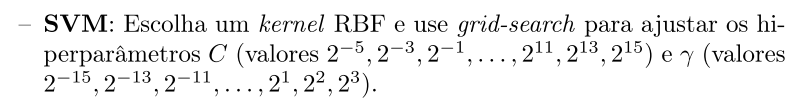

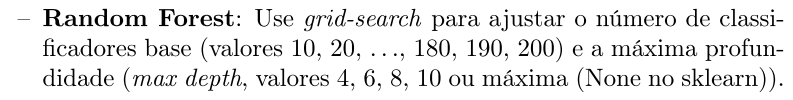

##### Grid Modelos

In [9]:
external_kfold = 10
internal_kfold = 10

methods_summary = {
    'SVM': {'class': SVC, 'scale': True},
    'RF' : {'class': RandomForestClassifier, 'scale': False}
}

c_range = [2**i for i in range(-5, 16, 2)]      # 2^-5, 2^-3, ..., 2^15
gamma_range = [2**i for i in range(-15, 4, 2)]  # 2^-15, 2^-13, ..., 2^3

methods_summary['SVM']['grid'] = {
    'C': c_range,
    'gamma': gamma_range,
    'kernel': ['rbf'],
    'random_state': [42]
}

n_estimators_range = list(range(10, 201, 10))  # 10, 20, ..., 200
max_depth_range = [4, 6, 8, 10, None]

methods_summary['RF']['grid'] = {
    'n_estimators': n_estimators_range,
    'max_depth': max_depth_range,
    'random_state': [42]
}

trained_models = {}
for method, info in methods_summary.items():
    print(f"\n[{method}] Running nested K-fold...")
    metrics, best_model = run_nested_cv(x=X, y=y, model_class=info['class'],
                                        grid=info['grid'], scale_flag=info['scale'],
                                        external_kfold=external_kfold, internal_kfold=internal_kfold)
    trained_models[method] = {'metrics': metrics, 'model': best_model}

# Results
results = { method : {key: info['metrics'][key] for key in ['acc', 'rec', 'prec', 'f1', 'roc_auc', 'pr_auc']} for method, info in trained_models.items() }
results_curves = { method : {key: info['metrics'][key] for key in ['roc_curve', 'pr_curve']} for method, info in trained_models.items() }
results_conf_mats = { method : info['metrics']['conf_mat'] for method, info in trained_models.items() }


[SVM] Running nested K-fold...
Fold 1: Best Params {'C': 8192.0, 'gamma': 0.0078125, 'kernel': 'rbf', 'random_state': 42} | Acc: 0.8450
Fold 2: Best Params {'C': 512.0, 'gamma': 0.125, 'kernel': 'rbf', 'random_state': 42} | Acc: 0.8650
Fold 3: Best Params {'C': 8192.0, 'gamma': 0.0078125, 'kernel': 'rbf', 'random_state': 42} | Acc: 0.8650
Fold 4: Best Params {'C': 8.0, 'gamma': 0.125, 'kernel': 'rbf', 'random_state': 42} | Acc: 0.8250
Fold 5: Best Params {'C': 8192.0, 'gamma': 0.0078125, 'kernel': 'rbf', 'random_state': 42} | Acc: 0.8450
Fold 6: Best Params {'C': 8192.0, 'gamma': 0.0078125, 'kernel': 'rbf', 'random_state': 42} | Acc: 0.8400
Fold 7: Best Params {'C': 2.0, 'gamma': 0.5, 'kernel': 'rbf', 'random_state': 42} | Acc: 0.8550
Fold 8: Best Params {'C': 2048.0, 'gamma': 0.0078125, 'kernel': 'rbf', 'random_state': 42} | Acc: 0.8150
Fold 9: Best Params {'C': 32.0, 'gamma': 0.03125, 'kernel': 'rbf', 'random_state': 42} | Acc: 0.8650
Fold 10: Best Params {'C': 128.0, 'gamma': 0.031

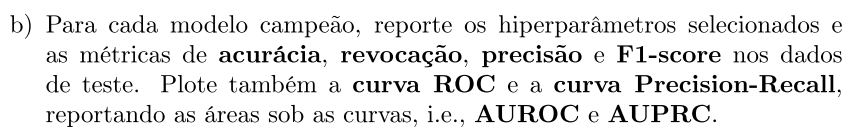

## Tabela de Resultados

In [10]:
table = pd.DataFrame(results).T
table[table.columns.difference(['roc_auc', 'pr_auc'])] = table[table.columns.difference(['roc_auc', 'pr_auc'])].map(lambda x: f"{np.mean(x):.2%} +- {1.96*np.std(x)/np.sqrt(len(x)):.2%}")
table[['roc_auc', 'pr_auc']] = table[['roc_auc', 'pr_auc']].map(lambda x: f"{np.mean(x):2.2f} +- {1.96*np.std(x)/np.sqrt(len(x)):2.2f}")
table.columns = ['Accuracy', 'Recall', 'Precision', 'F1-score', 'ROC-AUC', 'PR-AUC']
table.index = results.keys()
def extract_from_text(text):
    return float(text.split('%')[0]) if '%' in text else float(text.split('+-')[0])
table.style.apply(lambda col: [ 'font-weight:bold; color:red' if extract_from_text(x)==col.apply(extract_from_text).max() else '' for x in col ])

,Accuracy,Recall,Precision,F1-score,ROC-AUC,PR-AUC
SVM,84.85% +- 1.06%,85.32% +- 1.93%,84.56% +- 2.06%,84.86% +- 1.24%,0.85 +- 0.01,0.89 +- 0.01
RF,86.55% +- 1.30%,86.04% +- 1.59%,87.00% +- 2.44%,86.45% +- 1.36%,0.94 +- 0.01,0.94 +- 0.01


#### Plot dos gráficos

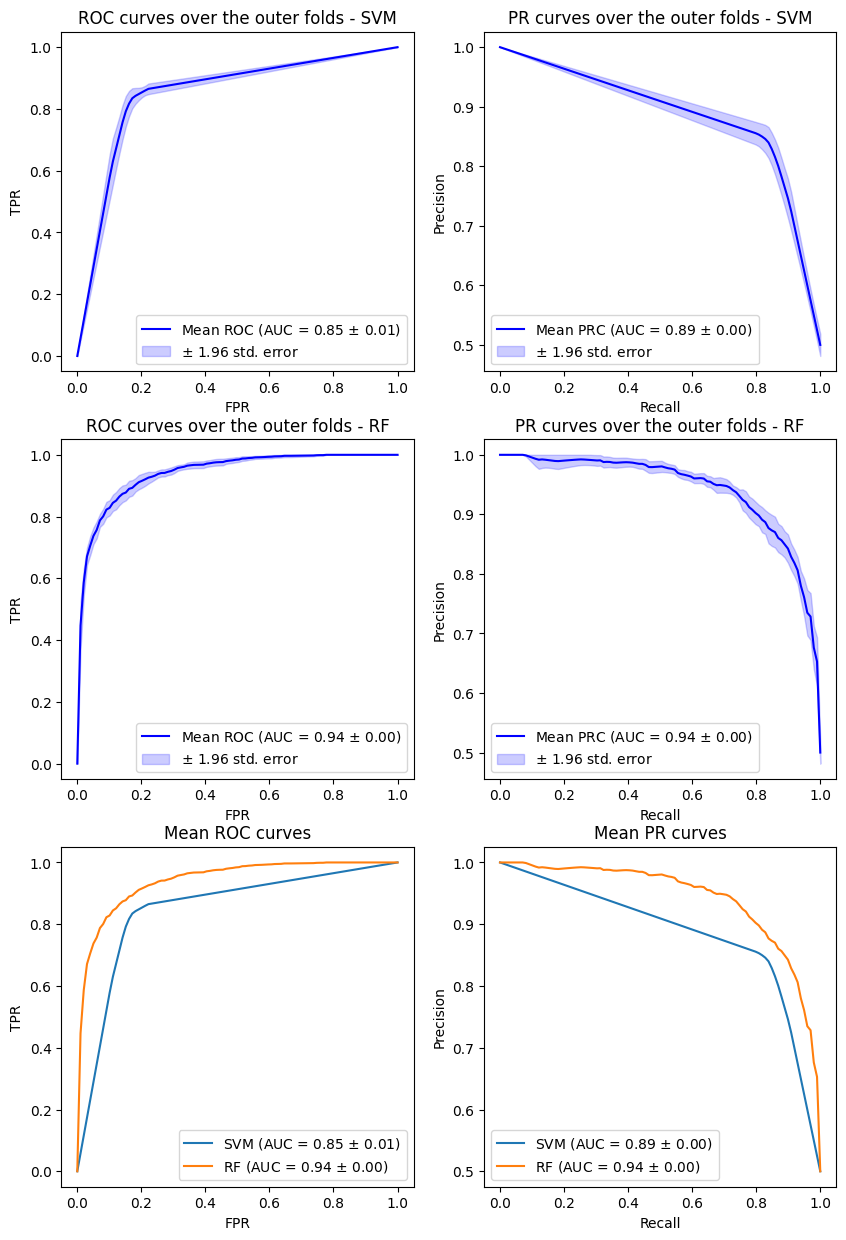

In [11]:
fig, axs = plt.subplots(1+len(results_curves), 2, figsize=(10, (1+len(results_curves)) * 5))
for i, (method, curves) in enumerate(results_curves.items()):
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = results[method]['roc_auc']
    for curve in curves['roc_curve']:
        fpr, tpr, t = curve
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    std_tpr = np.std(tprs, axis=0) / np.sqrt(len(tprs))
    tprs_upper = np.minimum(mean_tpr + 1.96*std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - 1.96*std_tpr, 0)
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs) / np.sqrt(len(aucs))

    axs[-1,0].plot(mean_fpr, mean_tpr, label=fr'{method} (AUC = {mean_auc:0.2f} $\pm$ {std_auc:0.2f})')
    axs[-1,0].set_xlabel("FPR")
    axs[-1,0].set_ylabel("TPR")
    axs[-1,0].set_title("Mean ROC curves")
    axs[-1,0].legend()

    axs[i,0].plot(mean_fpr, mean_tpr, color='blue', label=fr'Mean ROC (AUC = {mean_auc:0.2f} $\pm$ {std_auc:0.2f})')
    axs[i,0].fill_between(mean_fpr, tprs_lower, tprs_upper, color='blue', alpha=.2, label=r'$\pm$ 1.96 std. error')
    axs[i,0].set_xlabel("FPR")
    axs[i,0].set_ylabel("TPR")
    axs[i,0].set_title(f"ROC curves over the outer folds - {method}")
    axs[i,0].legend()

    mean_rec = np.linspace(0, 1, 100)
    prcs = []
    aucs = results[method]['pr_auc']
    for curve in curves['pr_curve']:
        prc, rec, t = curve
        interp_prc = np.interp(mean_rec, rec[::-1], prc[::-1])
        prcs.append(interp_prc)
        aucs.append(auc(rec[::-1], prc[::-1]))

    mean_prc = np.mean(prcs, axis=0)
    std_prc = np.std(prcs, axis=0) / np.sqrt(len(prcs))
    prcs_upper = np.minimum(mean_prc + 1.96*std_prc, 1)
    prcs_lower = np.maximum(mean_prc - 1.96*std_prc, 0)
    mean_auc = auc(mean_rec, mean_prc)
    std_auc = np.std(aucs) / np.sqrt(len(aucs))

    axs[-1,1].plot(mean_rec, mean_prc, label=fr'{method} (AUC = {mean_auc:0.2f} $\pm$ {std_auc:0.2f})')
    axs[-1,1].set_xlabel("Recall")
    axs[-1,1].set_ylabel("Precision")
    axs[-1,1].set_title("Mean PR curves")
    axs[-1,1].legend()

    axs[i,1].plot(mean_rec, mean_prc, color='blue', label=fr'Mean PRC (AUC = {mean_auc:0.2f} $\pm$ {std_auc:0.2f})')
    axs[i,1].fill_between(mean_rec, prcs_lower, prcs_upper, color='blue', alpha=.2, label=r'$\pm$ 1.96 std. error')
    axs[i,1].set_xlabel("Recall")
    axs[i,1].set_ylabel("Precision")
    axs[i,1].set_title(f"PR curves over the outer folds - {method}")
    axs[i,1].legend()

## Matriz de Confusão

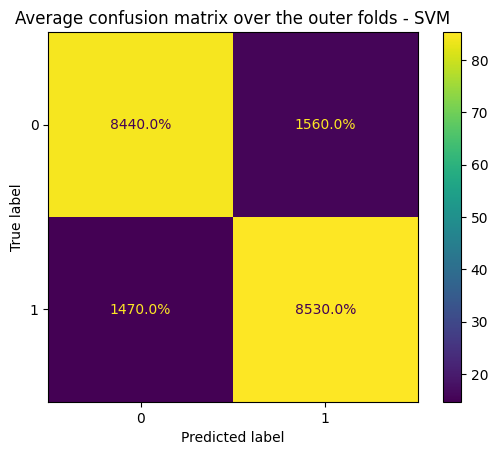

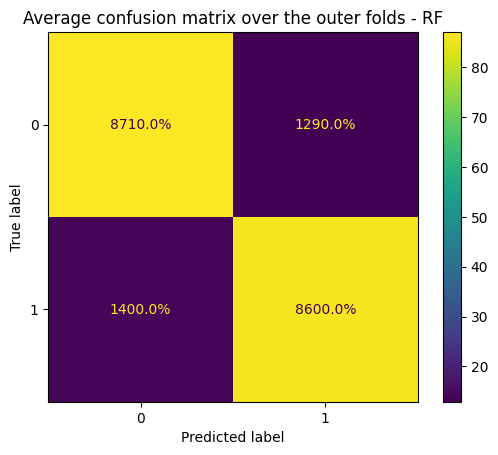

In [12]:
for i, (method, conf_mat) in enumerate(results_conf_mats.items()):
    ConfusionMatrixDisplay(np.mean(conf_mat, axis=0)).plot(values_format=".1%")
    plt.title(f"Average confusion matrix over the outer folds - {method}")